This Notebook is for comparing multiple optimizers for the P300NN

In [5]:
import mne
import numpy as np
from numpy import matlib as mb
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import warnings
from sklearn import metrics
from collections import defaultdict
import regex as re
from sklearn.metrics import accuracy_score
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)
from sklearn.metrics import roc_auc_score
from models.P300NN import P300NNClassifier
from src.Dataset import Dataset
from src.Speller import Speller
warnings.filterwarnings("ignore", category=RuntimeWarning)
mne.set_log_level("WARNING")
import tensorflow as tf
print("GPUs available:", tf.config.list_physical_devices('GPU'))
print("CPUs available:", tf.config.list_physical_devices('CPU'))
print("TF use:", tf.test.gpu_device_name() if tf.test.gpu_device_name() else "CPU")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CPUs available: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
TF use: /device:GPU:0


I0000 00:00:1777089779.286991 2337091 gpu_device.cc:2043] Created device /device:GPU:0 with 1037 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:17:00.0, compute capability: 8.6
I0000 00:00:1777089779.304590 2337091 gpu_device.cc:2043] Created device /device:GPU:0 with 1037 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:17:00.0, compute capability: 8.6


Divide and Separate Training and Testing Paths

In [6]:
def group_paths_by_participant(data_paths):
    participant_files = defaultdict(lambda: {'train': [], 'test': []})
    for path in data_paths:
        parts = path.split(os.sep)
        participant_id = parts[6]

        if 'Train' in path or 'train' in path:
            participant_files[participant_id]['train'].append(path)
        elif 'Test' in path or 'test' in path:
            participant_files[participant_id]['test'].append(path)
        else:
            print(f"Unclassified path: {path}")

    return participant_files


In [7]:
important_channels = ['EEG_Fz', 'EEG_Cz', 'EEG_Pz', 'EEG_P3',
                      'EEG_PO7', 'EEG_PO8', 'EEG_P4', 'EEG_Oz']

#first using default values
ds = Dataset(
    glob_path=os.path.join(project_root, "data", "*", "*", "*", "CB", "*"),
    tmin=0,
    tmax=0.8, 
)

participant_files = group_paths_by_participant(ds.data_paths)
participants = list(participant_files.keys())

Optimizer Evaluation ADAM
Processing participant L_01 with adam
Epoch 1/3000


I0000 00:00:1777090509.846914 2349417 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_113544__.48
I0000 00:00:1777090513.894781 2349416 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_113544__.48


119/119 - 10s - 87ms/step - accuracy: 0.5061 - loss: 0.6980
Epoch 2/3000
119/119 - 2s - 19ms/step - accuracy: 0.5860 - loss: 0.6938
Epoch 3/3000
119/119 - 0s - 3ms/step - accuracy: 0.3317 - loss: 0.6942
Epoch 4/3000
119/119 - 0s - 3ms/step - accuracy: 0.3249 - loss: 0.6941
Epoch 5/3000
119/119 - 0s - 3ms/step - accuracy: 0.4794 - loss: 0.6942
Epoch 6/3000
119/119 - 0s - 3ms/step - accuracy: 0.4487 - loss: 0.6942
Epoch 7/3000
119/119 - 0s - 3ms/step - accuracy: 0.5995 - loss: 0.6939
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
Processing participant L_02 with adam
Epoch 1/3000


I0000 00:00:1777090529.154045 2349417 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_122223__.48
I0000 00:00:1777090533.210537 2349417 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_122223__.48


119/119 - 11s - 90ms/step - accuracy: 0.4817 - loss: 0.7195
Epoch 2/3000
119/119 - 2s - 18ms/step - accuracy: 0.5455 - loss: 0.6882
Epoch 3/3000
119/119 - 0s - 4ms/step - accuracy: 0.6061 - loss: 0.6416
Epoch 4/3000
119/119 - 0s - 3ms/step - accuracy: 0.6624 - loss: 0.6222
Epoch 5/3000
119/119 - 0s - 3ms/step - accuracy: 0.6325 - loss: 0.6401
Epoch 6/3000
119/119 - 1s - 6ms/step - accuracy: 0.6495 - loss: 0.6219
Epoch 7/3000
119/119 - 1s - 5ms/step - accuracy: 0.6638 - loss: 0.6262
Epoch 8/3000
119/119 - 0s - 4ms/step - accuracy: 0.6444 - loss: 0.6292
Epoch 9/3000
119/119 - 0s - 3ms/step - accuracy: 0.6312 - loss: 0.6374
Epoch 10/3000
119/119 - 0s - 3ms/step - accuracy: 0.6262 - loss: 0.6229
Epoch 11/3000
119/119 - 0s - 3ms/step - accuracy: 0.6889 - loss: 0.6138
Epoch 12/3000
119/119 - 1s - 6ms/step - accuracy: 0.6865 - loss: 0.6054
Epoch 13/3000
119/119 - 0s - 3ms/step - accuracy: 0.6772 - loss: 0.6048
Epoch 14/3000
119/119 - 0s - 4ms/step - accuracy: 0.6799 - loss: 0.6158
Epoch 15/30

...

119/119 - 9s - 73ms/step - accuracy: 0.4844 - loss: 0.7001
Epoch 2/3000
119/119 - 3s - 26ms/step - accuracy: 0.5378 - loss: 0.6938
Epoch 3/3000
119/119 - 0s - 3ms/step - accuracy: 0.5275 - loss: 0.6943
Epoch 4/3000
119/119 - 0s - 3ms/step - accuracy: 0.4262 - loss: 0.6944
Epoch 5/3000
119/119 - 0s - 3ms/step - accuracy: 0.3384 - loss: 0.6950
Epoch 6/3000
119/119 - 0s - 3ms/step - accuracy: 0.3825 - loss: 0.6950
Epoch 7/3000
119/119 - 0s - 3ms/step - accuracy: 0.5489 - loss: 0.6945
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
Optimizer Evaluation ADAMW
Processing participant L_01 with adamw
Epoch 1/3000


I0000 00:00:1777090590.745744 2349417 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_152104__.48
I0000 00:00:1777090594.809484 2349416 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_152104__.48


119/119 - 10s - 88ms/step - accuracy: 0.4910 - loss: 0.6917
Epoch 2/3000
119/119 - 2s - 18ms/step - accuracy: 0.6595 - loss: 0.6961
Epoch 3/3000
119/119 - 0s - 4ms/step - accuracy: 0.6688 - loss: 0.6843
Epoch 4/3000
119/119 - 0s - 4ms/step - accuracy: 0.6291 - loss: 0.6806
Epoch 5/3000
119/119 - 0s - 3ms/step - accuracy: 0.5646 - loss: 0.6942
Epoch 6/3000
119/119 - 0s - 3ms/step - accuracy: 0.5910 - loss: 0.6943
Epoch 7/3000
119/119 - 1s - 6ms/step - accuracy: 0.4770 - loss: 0.6942
Epoch 8/3000
119/119 - 0s - 3ms/step - accuracy: 0.5077 - loss: 0.6942
Epoch 9/3000
119/119 - 0s - 3ms/step - accuracy: 0.5820 - loss: 0.6939
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
Processing participant L_02 with adamw
Epoch 1/3000


I0000 00:00:1777090610.801970 2349417 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_161973__.48
I0000 00:00:1777090614.891007 2349416 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_161973__.48


119/119 - 10s - 88ms/step - accuracy: 0.3913 - loss: 0.7028
Epoch 2/3000
119/119 - 0s - 4ms/step - accuracy: 0.4545 - loss: 0.6971
Epoch 3/3000
119/119 - 0s - 3ms/step - accuracy: 0.3894 - loss: 0.6939
Epoch 4/3000
119/119 - 1s - 6ms/step - accuracy: 0.6344 - loss: 0.6940
Epoch 5/3000
119/119 - 1s - 5ms/step - accuracy: 0.6153 - loss: 0.6938
Epoch 6/3000
119/119 - 0s - 3ms/step - accuracy: 0.5778 - loss: 0.6939
Epoch 7/3000
119/119 - 0s - 3ms/step - accuracy: 0.3444 - loss: 0.6943
Epoch 8/3000
119/119 - 0s - 4ms/step - accuracy: 0.4196 - loss: 0.6943
Epoch 9/3000
119/119 - 0s - 4ms/step - accuracy: 0.4587 - loss: 0.6936
Epoch 10/3000
119/119 - 0s - 3ms/step - accuracy: 0.5958 - loss: 0.6938
Epoch 11/3000
119/119 - 0s - 3ms/step - accuracy: 0.3196 - loss: 0.6935
Epoch 12/3000
119/119 - 0s - 4ms/step - accuracy: 0.4757 - loss: 0.6943
Epoch 13/3000
119/119 - 0s - 3ms/step - accuracy: 0.5947 - loss: 0.6945
Epoch 14/3000
119/119 - 1s - 6ms/step - accuracy: 0.6153 - loss: 0.6946
Epoch 15/300

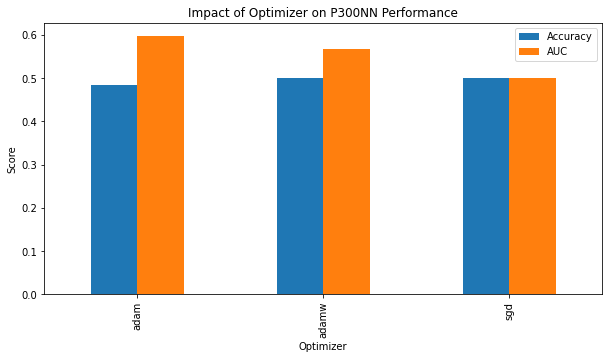

In [9]:
optims = ['adam', 'sgd', 'adamw']
optim_res = []

for opt in optims:
    print(f"Optimizer Evaluation {opt.upper()}")
    
    for participant_id in list(participant_files.keys())[:2]: 
        print(f"Processing participant {participant_id} with {opt}")

        train_files = participant_files[participant_id]['train']
        test_files = participant_files[participant_id]['test']

        X_train, y_train, X_test, y_test = [], [], [], []

        # Load data
        for path in train_files:
            ds = Dataset(path, important_channels=important_channels, sample_rate=256, tmin=0, tmax=0.8, use_car=True, notch_filter=True)
            X, y = ds[0]
            X_train.append(X)
            y_train.append(y)

        for path in test_files:
            ds = Dataset(path, important_channels=important_channels, sample_rate=256, tmin=0, tmax=0.8, use_car=True, notch_filter=True)
            X, y = ds[0]
            X_test.append(X)
            y_test.append(y)

        X_train = np.vstack(X_train)[..., np.newaxis]
        y_train = np.concatenate(y_train)
        X_test = np.vstack(X_test)[..., np.newaxis]
        y_test = np.concatenate(y_test)

        # Train with varied optimizr
        clf = P300NNClassifier(optim_type=opt)
        clf.train(X_train, y_train)

        # Evaluate
        probs = clf.model.predict(X_test)
        y_pred = np.argmax(probs, axis=1)
        scores = probs[:, 1] - probs[:, 0]
        
        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, scores)

        optim_res.append({
            "Optimizer": opt,
            "Participant": participant_id,
            "Accuracy": acc,
            "AUC": auc
        })

comparison_df = pd.DataFrame(optim_res)
optimizer_summary = comparison_df.groupby("Optimizer")[["Accuracy", "AUC"]].mean()

print(" Optimizer Comparison")
print(optimizer_summary)

optimizer_summary.plot(kind='bar', figsize=(10, 5))
plt.title("Impact of Optimizer on P300NN Performance")
plt.ylabel("Score")
plt.show()

Three optimizers, Adam, AdamW, and SGD, were compared on the P300 neural network implementation across Accuracy and AUC metrics.
Adam achieved the highest AUC (0.60) but the lowest accuracy (0.48), suggesting it learns more discriminative features but may be less stable in classification. AdamW offered a good middle state with 0.50 accuracy and 0.57 AUC. SGD performed equally on both metrics at 0.50, indicating it is not very effective at generalizing to the data. Overall, Adam appears to be the best optimizer to move forward with but some additional changes may be needed for the model to perform its best.